# Brain Tumor Classification & Segmentation — Kaggle

**Before running anything:**
1. Right sidebar → **+ Add Input** → search `brisc2025` → add `briscdataset/brisc2025`
2. Notebook settings → **Accelerator → GPU T4 x2**
3. Notebook settings → **Internet → On**
4. Run cells top to bottom

**Save Version** (top right) after each model finishes training — this permanently saves checkpoints in `/kaggle/working/`.

---

## 1. Environment & Dataset Setup

The experiments are performed in the Kaggle environment using the BRISC2025 dataset already attached to the notebook.

No external download or Google Drive mounting is required. The dataset contains separate classification and segmentation tasks, which are used in the later experiments.

In this section, I:
- verify the dataset location and directory structure,
- install the libraries required for the experiments, and
- create the working directories used to store code, data splits, and experiment results.

In [1]:
# Install libraries required for the experiments
!pip install -q segmentation-models-pytorch albumentations monai thop timm

import os

# Dataset paths
DATA_ROOT = '/kaggle/input/datasets/briscdataset/brisc2025/brisc2025'

PATH_CLS = os.path.join(DATA_ROOT, 'classification_task')
PATH_SEG = os.path.join(DATA_ROOT, 'segmentation_task')

# Project workspace
PROJECT_ROOT = '/kaggle/working/brain-tumor-study'

for subdir in [
    'src',
    'data/splits',
    'results/classification',
    'results/segmentation'
]:
    os.makedirs(os.path.join(PROJECT_ROOT, subdir), exist_ok=True)

print("Dataset root       :", DATA_ROOT)
print("Classification data:", PATH_CLS)
print("Segmentation data  :", PATH_SEG)
print("Project workspace  :", PROJECT_ROOT)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 47.6 MB/s eta 0:00:0000:01
Dataset root       : /kaggle/input/datasets/briscdataset/brisc2025/brisc2025
Classification data: /kaggle/input/datasets/briscdataset/brisc2025/brisc2025/classification_task
Segmentation data  : /kaggle/input/datasets/briscdataset/brisc2025/brisc2025/segmentation_task
Project workspace  : /kaggle/working/brain-tumor-study


In [2]:
# Verify that the dataset is available and inspect its structure

print("Dataset contents:")
for item in sorted(os.listdir(DATA_ROOT)):
    print(f"  - {item}")

print("\nClassification task:")
for item in sorted(os.listdir(PATH_CLS)):
    print(f"  - {item}")

print("\nSegmentation task:")
for item in sorted(os.listdir(PATH_SEG)):
    print(f"  - {item}")

Dataset contents:
  - README.md
  - classification_task
  - manifest.csv
  - manifest.csv.sha256
  - manifest.json
  - manifest.json.sha256
  - segmentation_task

Classification task:
  - test
  - train

Segmentation task:
  - test
  - train


### Dataset Structure

The BRISC2025 dataset used in this project contains two tasks:

- **Classification:** used to classify the MRI images into the available tumor categories.
- **Segmentation:** used to identify the tumor region using pixel-level masks.

The segmentation pipeline works with corresponding MRI images and ground-truth masks.

In [3]:
# Inspect the segmentation dataset

train_images = os.path.join(PATH_SEG, 'train', 'images')
train_masks = os.path.join(PATH_SEG, 'train', 'masks')
test_images = os.path.join(PATH_SEG, 'test', 'images')
test_masks = os.path.join(PATH_SEG, 'test', 'masks')

print("Segmentation dataset:")
print(f"  Training images : {len(os.listdir(train_images))}")
print(f"  Training masks  : {len(os.listdir(train_masks))}")
print(f"  Test images     : {len(os.listdir(test_images))}")
print(f"  Test masks      : {len(os.listdir(test_masks))}")

Segmentation dataset:
  Training images : 3933
  Training masks  : 3933
  Test images     : 860
  Test masks      : 860


## 2. Shared Utilities

### Purpose

I created a small utility module to keep common functionality in one place instead of repeating the same code across different experiments.

The utilities are used for:

- setting random seeds for reproducible experiments,
- saving and loading experiment information in JSON format, and
- stopping training when the validation metric stops improving.

In [4]:
# Create common utilities used throughout the experiments

code = """
import random
import os
import json
import numpy as np
import torch


def set_seed(seed):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def save_json(obj, path):
    with open(path, 'w') as f:
        json.dump(obj, f, indent=2)


def load_json(path):
    with open(path) as f:
        return json.load(f)


class EarlyStopping:
    def __init__(self, patience=10, mode='max'):
        self.patience = patience
        self.mode = mode
        self.best = None
        self.counter = 0
        self.should_stop = False

    def step(self, value):
        if self.best is None:
            self.best = value
            return False

        improved = (
            value > self.best
            if self.mode == 'max'
            else value < self.best
        )

        if improved:
            self.best = value
            self.counter = 0
        else:
            self.counter += 1

            if self.counter >= self.patience:
                self.should_stop = True

        return self.should_stop
"""

with open(f'{PROJECT_ROOT}/src/utils.py', 'w') as f:
    f.write(code)

print("Created:", f'{PROJECT_ROOT}/src/utils.py')

Created: /kaggle/working/brain-tumor-study/src/utils.py


## 3. Reproducible Train / Validation / Test Split

The segmentation dataset provided with BRISC2025 contains separate training and test sets. 
For the experiments in this notebook, I further divide the provided training set into 
training, validation, and an internal test set.

A fixed random seed (`42`) is used so that the same samples are assigned to each split 
whenever the experiment is repeated.

The split used for segmentation is:

- **70%** → Training
- **15%** → Validation
- **15%** → Internal test

The original BRISC2025 test set is kept untouched and is not used when creating these 
internal splits. This allows the final test set to remain separate from the data used 
during model development.

In [5]:
# Create the utility used to generate the segmentation split

import os
import glob
import random
import json

code = """
import os
import glob
import random
import json


def make_segmentation_split(
    seg_train_dir,
    out_path,
    val_fraction=0.15,
    test_fraction=0.15,
    seed=42
):
    random.seed(seed)

    images_dir = os.path.join(seg_train_dir, 'images')

    files = sorted(
        glob.glob(os.path.join(images_dir, '*.jpg'))
    )

    basenames = [
        os.path.splitext(os.path.basename(f))[0]
        for f in files
    ]

    random.shuffle(basenames)

    n = len(basenames)
    n_val = int(n * val_fraction)
    n_test = int(n * test_fraction)

    split = {
        'train': basenames[n_val + n_test:],
        'val': basenames[:n_val],
        'test_internal': basenames[n_val:n_val + n_test]
    }

    with open(out_path, 'w') as f:
        json.dump(split, f, indent=2)

    print(
        f'Segmentation split: '
        f'{len(split["train"])} train, '
        f'{len(split["val"])} val, '
        f'{len(split["test_internal"])} internal test'
    )

    return split
"""

utils_path = f'{PROJECT_ROOT}/src/make_splits.py'

with open(utils_path, 'w') as f:
    f.write(code)

print("Created:", utils_path)

Created: /kaggle/working/brain-tumor-study/src/make_splits.py


In [6]:
import sys

sys.path.append(f'{PROJECT_ROOT}/src')

from make_splits import make_segmentation_split

seg_split = make_segmentation_split(
    seg_train_dir=f'{PATH_SEG}/train',
    out_path=f'{PROJECT_ROOT}/data/splits/segmentation_split.json'
)

print('Segmentation split saved.')

Segmentation split: 2755 train, 589 val, 589 internal test
Segmentation split saved.


In [7]:
# Generate the fixed segmentation split

import sys

if f'{PROJECT_ROOT}/src' not in sys.path:
    sys.path.append(f'{PROJECT_ROOT}/src')

from make_splits import make_segmentation_split

seg_split = make_segmentation_split(
    seg_train_dir=f'{PATH_SEG}/train',
    out_path=f'{PROJECT_ROOT}/data/splits/segmentation_split.json',
    val_fraction=0.15,
    test_fraction=0.15,
    seed=42
)

print("\nSplit file saved successfully.")

Segmentation split: 2755 train, 589 val, 589 internal test

Split file saved successfully.


In [8]:
print("Segmentation split")
print("-" * 40)
print(f"Training samples : {len(seg_split['train'])}")
print(f"Validation samples: {len(seg_split['val'])}")
print(f"Internal test samples: {len(seg_split['test_internal'])}")

total = (
    len(seg_split['train'])
    + len(seg_split['val'])
    + len(seg_split['test_internal'])
)

print(f"Total samples    : {total}")

Segmentation split
----------------------------------------
Training samples : 2755
Validation samples: 589
Internal test samples: 589
Total samples    : 3933


## 4. Preprocessing, Augmentation & Dataset Pipeline

For the segmentation experiments, the MRI images and their corresponding masks need to undergo the same spatial transformations so that the image and mask remain aligned.

The training pipeline uses augmentation to introduce variation in the training images, while the validation and internal test sets use only deterministic preprocessing.

The images are resized to **512 × 512** before being passed to the models.

The segmentation pipeline consists of:

- resizing,
- horizontal and vertical flipping,
- random 90° rotation,
- brightness/contrast adjustment,
- small affine transformations,
- Gaussian noise,
- normalization, and
- conversion to PyTorch tensors.

In [9]:
# Create and save segmentation augmentation utilities

code = """
import albumentations as A
from albumentations.pytorch import ToTensorV2


def get_segmentation_train_transforms(img_size=512):
    return A.Compose([
        A.Resize(img_size, img_size),

        # Spatial augmentations
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
        A.RandomRotate90(p=0.5),

        # Appearance and geometric variations
        A.RandomBrightnessContrast(
            brightness_limit=0.2,
            contrast_limit=0.2,
            p=0.3
        ),

        A.Affine(
            translate_percent=0.05,
            scale=(0.9, 1.1),
            rotate=(-15, 15),
            p=0.3
        ),

        A.GaussNoise(
            std_range=(0.04, 0.2),
            p=0.2
        ),

        # Normalize and convert to tensor
        A.Normalize(
            mean=[0.0, 0.0, 0.0],
            std=[1.0, 1.0, 1.0],
            max_pixel_value=255.0
        ),
        ToTensorV2(),
    ])


def get_segmentation_eval_transforms(img_size=512):
    return A.Compose([
        A.Resize(img_size, img_size),

        # No random augmentation during evaluation
        A.Normalize(
            mean=[0.0, 0.0, 0.0],
            std=[1.0, 1.0, 1.0],
            max_pixel_value=255.0
        ),
        ToTensorV2(),
    ])
"""

augmentations_path = f'{PROJECT_ROOT}/src/augmentations.py'

with open(augmentations_path, 'w') as f:
    f.write(code)

print("Created:", augmentations_path)

Created: /kaggle/working/brain-tumor-study/src/augmentations.py


In [10]:
# Create and save the segmentation Dataset and DataLoader utilities

code = """
import os
import numpy as np
import torch

from torch.utils.data import Dataset, DataLoader
from PIL import Image


class BRISCSegmentationDataset(Dataset):

    def __init__(
        self,
        basenames,
        images_dir,
        masks_dir,
        transform=None
    ):
        self.basenames = basenames
        self.images_dir = images_dir
        self.masks_dir = masks_dir
        self.transform = transform

    def __len__(self):
        return len(self.basenames)

    def __getitem__(self, idx):

        basename = self.basenames[idx]

        image_path = os.path.join(
            self.images_dir,
            basename + '.jpg'
        )

        mask_path = os.path.join(
            self.masks_dir,
            basename + '.png'
        )

        image = np.array(
            Image.open(image_path).convert('RGB')
        )

        mask = np.array(
            Image.open(mask_path).convert('L')
        )

        # Convert mask to binary values
        mask = (mask > 127).astype(np.float32)

        # Apply the same transformation to image and mask
        if self.transform:
            augmented = self.transform(
                image=image,
                mask=mask
            )

            image = augmented['image']
            mask = augmented['mask']

        # Add channel dimension to mask
        if isinstance(mask, torch.Tensor):
            if mask.ndim == 2:
                mask = mask.unsqueeze(0)
        else:
            mask = torch.from_numpy(mask).unsqueeze(0)

        return image, mask.float()


def get_segmentation_loaders(
    split_json,
    images_dir,
    masks_dir,
    batch_size,
    train_transform,
    eval_transform,
    num_workers=2
):

    train_ds = BRISCSegmentationDataset(
        split_json['train'],
        images_dir,
        masks_dir,
        train_transform
    )

    val_ds = BRISCSegmentationDataset(
        split_json['val'],
        images_dir,
        masks_dir,
        eval_transform
    )

    test_ds = BRISCSegmentationDataset(
        split_json['test_internal'],
        images_dir,
        masks_dir,
        eval_transform
    )

    train_loader = DataLoader(
        train_ds,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=True
    )

    val_loader = DataLoader(
        val_ds,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True
    )

    test_loader = DataLoader(
        test_ds,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True
    )

    return train_loader, val_loader, test_loader
"""

dataset_path = f'{PROJECT_ROOT}/src/brisc_datasets.py'

with open(dataset_path, 'w') as f:
    f.write(code)

print("Created:", dataset_path)

Created: /kaggle/working/brain-tumor-study/src/brisc_datasets.py


## Phase 5 — Segmentation Model Factory

6 architectures: U-Net, U-Net++, Attention U-Net, ResUNet, SegResNet, EfficientNet-B1-UNet.

In [11]:
# Build and verify the segmentation data pipeline

import sys

SRC_DIR = f'{PROJECT_ROOT}/src'

if SRC_DIR not in sys.path:
    sys.path.insert(0, SRC_DIR)

from augmentations import (
    get_segmentation_train_transforms,
    get_segmentation_eval_transforms
)

from brisc_datasets import (
    get_segmentation_loaders
)


# Create transforms
train_transform = get_segmentation_train_transforms(
    img_size=512
)

eval_transform = get_segmentation_eval_transforms(
    img_size=512
)


# Dataset paths
images_dir = f'{PATH_SEG}/train/images'
masks_dir = f'{PATH_SEG}/train/masks'


# Create DataLoaders
train_loader, val_loader, test_loader = get_segmentation_loaders(
    split_json=seg_split,
    images_dir=images_dir,
    masks_dir=masks_dir,
    batch_size=8,
    train_transform=train_transform,
    eval_transform=eval_transform,
    num_workers=2
)


print("Segmentation DataLoaders created successfully.")
print("-" * 45)
print(f"Training batches      : {len(train_loader)}")
print(f"Validation batches    : {len(val_loader)}")
print(f"Internal test batches : {len(test_loader)}")


# ---------------------------------------------------------------
# Sanity check: inspect one training batch
# ---------------------------------------------------------------

images, masks = next(iter(train_loader))

print("\nBatch verification")
print("-" * 45)
print(f"Image shape : {tuple(images.shape)}")
print(f"Mask shape  : {tuple(masks.shape)}")
print(f"Image dtype : {images.dtype}")
print(f"Mask dtype  : {masks.dtype}")
print(
    f"Mask values : "
    f"{masks.min().item():.0f} to {masks.max().item():.0f}"
)

Segmentation DataLoaders created successfully.
---------------------------------------------
Training batches      : 345
Validation batches    : 74
Internal test batches : 74

Batch verification
---------------------------------------------
Image shape : (8, 3, 512, 512)
Mask shape  : (8, 1, 512, 512)
Image dtype : torch.float32
Mask dtype  : torch.float32
Mask values : 0 to 1


## 5. Segmentation Model Architectures

For the segmentation experiments, I trained and compared five architectures:

1. U-Net++
2. Attention U-Net
3. ResUNet
4. EfficientNet-B1 U-Net
5. U-Net++ + EfficientNet-B1

The models are implemented through a single model factory so that the same training and evaluation pipeline can be used for all five architectures.


In [12]:
code = """
import torch
import torch.nn as nn
import torch.nn.functional as F
import segmentation_models_pytorch as smp


# ================================================================
# Segmentation models used in this project
# ================================================================

SEGMENTATION_MODEL_NAMES = [
    'unetplusplus',
    'attention_unet',
    'resunet',
    'efficientnet_b1_unet',
    'unetplusplus_efficientnet_b1',
]


# ================================================================
# Model factory
# ================================================================

def get_segmentation_model(
    name,
    encoder_name='resnet34',
    in_channels=3,
    classes=1
):

    # U-Net++
    if name == 'unetplusplus':
        return smp.UnetPlusPlus(
            encoder_name=encoder_name,
            encoder_weights='imagenet',
            in_channels=in_channels,
            classes=classes
        )

    # EfficientNet-B1 + U-Net
    if name == 'efficientnet_b1_unet':
        return smp.Unet(
            encoder_name='efficientnet-b1',
            encoder_weights='imagenet',
            in_channels=in_channels,
            classes=classes
        )

    # EfficientNet-B1 + U-Net++
    if name == 'unetplusplus_efficientnet_b1':
        return smp.UnetPlusPlus(
            encoder_name='efficientnet-b1',
            encoder_weights='imagenet',
            in_channels=in_channels,
            classes=classes
        )

    # Attention U-Net
    if name == 'attention_unet':
        return AttentionUNet(
            in_channels=in_channels,
            out_channels=classes
        )

    # ResUNet
    if name == 'resunet':
        return ResUNet(
            in_channels=in_channels,
            out_channels=classes
        )

    raise ValueError(
        f'Unknown segmentation model: {name}'
    )


# ================================================================
# Parameter counting
# ================================================================

def count_parameters(model):

    total = sum(
        p.numel()
        for p in model.parameters()
    )

    trainable = sum(
        p.numel()
        for p in model.parameters()
        if p.requires_grad
    )

    return total, trainable


# ================================================================
# Attention U-Net
# ================================================================

def _conv_block(in_ch, out_ch):

    return nn.Sequential(
        nn.Conv2d(
            in_ch,
            out_ch,
            kernel_size=3,
            padding=1
        ),
        nn.BatchNorm2d(out_ch),
        nn.ReLU(inplace=True),

        nn.Conv2d(
            out_ch,
            out_ch,
            kernel_size=3,
            padding=1
        ),
        nn.BatchNorm2d(out_ch),
        nn.ReLU(inplace=True),
    )


class AttentionGate(nn.Module):

    def __init__(
        self,
        gate_ch,
        skip_ch,
        inter_ch
    ):
        super().__init__()

        self.W_gate = nn.Conv2d(
            gate_ch,
            inter_ch,
            kernel_size=1
        )

        self.W_skip = nn.Conv2d(
            skip_ch,
            inter_ch,
            kernel_size=1
        )

        self.psi = nn.Conv2d(
            inter_ch,
            1,
            kernel_size=1
        )

        self.relu = nn.ReLU(inplace=True)
        self.sig = nn.Sigmoid()

    def forward(self, gate, skip):

        g = self.W_gate(gate)
        s = self.W_skip(skip)

        if g.shape[-2:] != s.shape[-2:]:
            g = F.interpolate(
                g,
                size=s.shape[-2:],
                mode='bilinear',
                align_corners=False
            )

        attention = self.sig(
            self.psi(
                self.relu(g + s)
            )
        )

        return skip * attention


class AttentionUNet(nn.Module):

    def __init__(
        self,
        in_channels=3,
        out_channels=1,
        base_channels=32
    ):
        super().__init__()

        c = base_channels

        # Encoder
        self.enc1 = _conv_block(
            in_channels, c
        )

        self.enc2 = _conv_block(
            c, c * 2
        )

        self.enc3 = _conv_block(
            c * 2, c * 4
        )

        self.enc4 = _conv_block(
            c * 4, c * 8
        )

        self.pool = nn.MaxPool2d(2)

        # Bottleneck
        self.bottleneck = _conv_block(
            c * 8, c * 16
        )

        # Decoder
        self.up4 = nn.ConvTranspose2d(
            c * 16,
            c * 8,
            kernel_size=2,
            stride=2
        )

        self.att4 = AttentionGate(
            c * 8,
            c * 8,
            c * 4
        )

        self.dec4 = _conv_block(
            c * 16,
            c * 8
        )

        self.up3 = nn.ConvTranspose2d(
            c * 8,
            c * 4,
            kernel_size=2,
            stride=2
        )

        self.att3 = AttentionGate(
            c * 4,
            c * 4,
            c * 2
        )

        self.dec3 = _conv_block(
            c * 8,
            c * 4
        )

        self.up2 = nn.ConvTranspose2d(
            c * 4,
            c * 2,
            kernel_size=2,
            stride=2
        )

        self.att2 = AttentionGate(
            c * 2,
            c * 2,
            c
        )

        self.dec2 = _conv_block(
            c * 4,
            c * 2
        )

        self.up1 = nn.ConvTranspose2d(
            c * 2,
            c,
            kernel_size=2,
            stride=2
        )

        self.att1 = AttentionGate(
            c,
            c,
            c // 2
        )

        self.dec1 = _conv_block(
            c * 2,
            c
        )

        self.final = nn.Conv2d(
            c,
            out_channels,
            kernel_size=1
        )

    def forward(self, x):

        # Encoder
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))

        # Bottleneck
        b = self.bottleneck(
            self.pool(e4)
        )

        # Decoder
        u4 = self.up4(b)
        a4 = self.att4(u4, e4)
        d4 = self.dec4(
            torch.cat([u4, a4], dim=1)
        )

        u3 = self.up3(d4)
        a3 = self.att3(u3, e3)
        d3 = self.dec3(
            torch.cat([u3, a3], dim=1)
        )

        u2 = self.up2(d3)
        a2 = self.att2(u2, e2)
        d2 = self.dec2(
            torch.cat([u2, a2], dim=1)
        )

        u1 = self.up1(d2)
        a1 = self.att1(u1, e1)
        d1 = self.dec1(
            torch.cat([u1, a1], dim=1)
        )

        return self.final(d1)


# ================================================================
# ResUNet
# ================================================================

class ResBlock(nn.Module):

    def __init__(
        self,
        in_ch,
        out_ch
    ):
        super().__init__()

        self.conv1 = nn.Conv2d(
            in_ch,
            out_ch,
            kernel_size=3,
            padding=1
        )

        self.bn1 = nn.BatchNorm2d(out_ch)

        self.conv2 = nn.Conv2d(
            out_ch,
            out_ch,
            kernel_size=3,
            padding=1
        )

        self.bn2 = nn.BatchNorm2d(out_ch)

        self.relu = nn.ReLU(inplace=True)

        self.skip = (
            nn.Conv2d(
                in_ch,
                out_ch,
                kernel_size=1
            )
            if in_ch != out_ch
            else nn.Identity()
        )

    def forward(self, x):

        residual = self.skip(x)

        x = self.relu(
            self.bn1(
                self.conv1(x)
            )
        )

        x = self.bn2(
            self.conv2(x)
        )

        return self.relu(
            x + residual
        )


class ResUNet(nn.Module):

    def __init__(
        self,
        in_channels=3,
        out_channels=1,
        base_channels=32
    ):
        super().__init__()

        c = base_channels

        # Encoder
        self.enc1 = ResBlock(
            in_channels,
            c
        )

        self.enc2 = ResBlock(
            c,
            c * 2
        )

        self.enc3 = ResBlock(
            c * 2,
            c * 4
        )

        self.enc4 = ResBlock(
            c * 4,
            c * 8
        )

        self.pool = nn.MaxPool2d(2)

        # Bottleneck
        self.bottleneck = ResBlock(
            c * 8,
            c * 16
        )

        # Decoder
        self.up4 = nn.ConvTranspose2d(
            c * 16,
            c * 8,
            kernel_size=2,
            stride=2
        )

        self.dec4 = ResBlock(
            c * 16,
            c * 8
        )

        self.up3 = nn.ConvTranspose2d(
            c * 8,
            c * 4,
            kernel_size=2,
            stride=2
        )

        self.dec3 = ResBlock(
            c * 8,
            c * 4
        )

        self.up2 = nn.ConvTranspose2d(
            c * 4,
            c * 2,
            kernel_size=2,
            stride=2
        )

        self.dec2 = ResBlock(
            c * 4,
            c * 2
        )

        self.up1 = nn.ConvTranspose2d(
            c * 2,
            c,
            kernel_size=2,
            stride=2
        )

        self.dec1 = ResBlock(
            c * 2,
            c
        )

        self.final = nn.Conv2d(
            c,
            out_channels,
            kernel_size=1
        )

    def forward(self, x):

        # Encoder
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))

        # Bottleneck
        b = self.bottleneck(
            self.pool(e4)
        )

        # Decoder
        d4 = self.dec4(
            torch.cat([
                self.up4(b),
                e4
            ], dim=1)
        )

        d3 = self.dec3(
            torch.cat([
                self.up3(d4),
                e3
            ], dim=1)
        )

        d2 = self.dec2(
            torch.cat([
                self.up2(d3),
                e2
            ], dim=1)
        )

        d1 = self.dec1(
            torch.cat([
                self.up1(d2),
                e1
            ], dim=1)
        )

        return self.final(d1)
"""

with open(
    f'{PROJECT_ROOT}/src/models_segmentation.py',
    'w'
) as f:
    f.write(code)

print("models_segmentation.py written successfully.")

models_segmentation.py written successfully.


In [13]:
# Verify the five segmentation models used in the experiments

import sys
import torch

sys.path.append(f'{PROJECT_ROOT}/src')

from models_segmentation import (
    get_segmentation_model,
    SEGMENTATION_MODEL_NAMES,
    count_parameters
)

dummy = torch.randn(1, 3, 512, 512)

print(
    f"{'Model':<32} "
    f"{'Output Shape':<20} "
    f"{'Parameters':>12}"
)
print("-" * 68)

for name in SEGMENTATION_MODEL_NAMES:

    model = get_segmentation_model(name)
    model.eval()

    with torch.no_grad():
        output = model(dummy)

    total, trainable = count_parameters(model)

    print(
        f"{name:<32} "
        f"{str(tuple(output.shape)):<20} "
        f"{total / 1e6:>9.2f} M"
    )

    del model

Model                            Output Shape           Parameters
--------------------------------------------------------------------


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

unetplusplus                     (1, 1, 512, 512)         26.08 M
attention_unet                   (1, 1, 512, 512)          7.85 M
resunet                          (1, 1, 512, 512)          8.12 M


config.json:   0%|          | 0.00/106 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/31.5M [00:00<?, ?B/s]

efficientnet_b1_unet             (1, 1, 512, 512)          8.76 M
unetplusplus_efficientnet_b1     (1, 1, 512, 512)          9.08 M


## 6. Segmentation Training Pipeline

A common training pipeline is used for all five segmentation models. This keeps the training procedure consistent so that the models can be compared under the same experimental settings.

The training pipeline includes:

- Dice loss and focal loss combined into a single training loss.
- Adam optimizer.
- Cosine annealing with warm restarts for learning-rate scheduling.
- Early stopping based on validation Dice.
- Saving the best model checkpoint based on validation Dice.
- Evaluation on the internal test split using Dice and IoU.
- Saving the training history and final experiment summary for later analysis.

The same pipeline is used for each model, while the model architecture is selected through the segmentation model factory created in the previous section.

In [14]:
# Create the segmentation training pipeline

code = """
import os
import time
import numpy as np
import torch

from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts

from models_segmentation import (
    get_segmentation_model,
    count_parameters
)

from brisc_datasets import get_segmentation_loaders

from augmentations import (
    get_segmentation_train_transforms,
    get_segmentation_eval_transforms
)

from utils import (
    set_seed,
    save_json,
    EarlyStopping
)


# ================================================================
# Loss functions
# ================================================================

def dice_loss(logits, targets, eps=1e-6):

    probs = torch.sigmoid(logits).view(
        logits.size(0), -1
    )

    tgts = targets.view(
        targets.size(0), -1
    )

    intersection = (probs * tgts).sum(1)

    dice = (
        (2 * intersection + eps)
        /
        (probs.sum(1) + tgts.sum(1) + eps)
    )

    return (1 - dice).mean()


def focal_loss(
    logits,
    targets,
    alpha=0.8,
    gamma=2.0,
    eps=1e-6
):

    probs = torch.clamp(
        torch.sigmoid(logits),
        eps,
        1 - eps
    )

    pt = torch.where(
        targets == 1,
        probs,
        1 - probs
    )

    alpha_t = torch.where(
        targets == 1,
        alpha,
        1 - alpha
    )

    return (
        -alpha_t
        * (1 - pt) ** gamma
        * torch.log(pt)
    ).mean()


def combined_loss(logits, targets):

    d = dice_loss(logits, targets)
    f = focal_loss(logits, targets)

    loss = 0.7 * d + 0.3 * f

    return loss, d.item(), f.item()


# ================================================================
# Evaluation metrics
# ================================================================

@torch.no_grad()
def compute_dice_iou(
    logits,
    targets,
    threshold=0.5,
    eps=1e-6
):

    predictions = (
        torch.sigmoid(logits) > threshold
    ).float()

    predictions = predictions.view(
        predictions.size(0), -1
    )

    targets = targets.view(
        targets.size(0), -1
    )

    intersection = (
        predictions * targets
    ).sum(1)

    union = (
        predictions.sum(1)
        + targets.sum(1)
        - intersection
    )

    dice = (
        (2 * intersection + eps)
        /
        (
            predictions.sum(1)
            + targets.sum(1)
            + eps
        )
    )

    iou = (
        (intersection + eps)
        /
        (union + eps)
    )

    return dice.mean().item(), iou.mean().item()


# ================================================================
# Training function
# ================================================================

def train_segmentation_model(
    model_name,
    project_root,
    seg_split,
    images_dir,
    masks_dir,
    seed=42,
    batch_size=4,
    lr=1e-4,
    max_epochs=60,
    patience=10,
    img_size=512,
    device=None
):

    set_seed(seed)

    device = device or (
        "cuda"
        if torch.cuda.is_available()
        else "cpu"
    )

    run_dir = os.path.join(
        project_root,
        "results",
        "segmentation",
        model_name,
        f"seed_{seed}"
    )

    os.makedirs(
        run_dir,
        exist_ok=True
    )

    # ------------------------------------------------------------
    # Data
    # ------------------------------------------------------------

    train_loader, val_loader, test_loader = (
        get_segmentation_loaders(
            seg_split,
            images_dir,
            masks_dir,
            batch_size=batch_size,
            train_transform=
                get_segmentation_train_transforms(img_size),
            eval_transform=
                get_segmentation_eval_transforms(img_size),
            num_workers=2
        )
    )

    # ------------------------------------------------------------
    # Model
    # ------------------------------------------------------------

    model = get_segmentation_model(
        model_name
    ).to(device)

    total_params, trainable_params = (
        count_parameters(model)
    )

    # ------------------------------------------------------------
    # Optimizer and scheduler
    # ------------------------------------------------------------

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=lr
    )

    scheduler = CosineAnnealingWarmRestarts(
        optimizer,
        T_0=10,
        T_mult=1
    )

    early_stopper = EarlyStopping(
        patience=patience,
        mode="max"
    )

    history = []

    best_val_dice = -1.0
    best_epoch = -1

    best_ckpt = os.path.join(
        run_dir,
        "best_model.pt"
    )

    print()
    print("=" * 60)
    print(f"Training: {model_name}")
    print(f"Device: {device} | Seed: {seed}")
    print("=" * 60)

    print(
        f"Total parameters: "
        f"{total_params / 1e6:.2f}M"
    )

    print(
        f"Trainable parameters: "
        f"{trainable_params / 1e6:.2f}M"
    )

    # ============================================================
    # Training loop
    # ============================================================

    for epoch in range(max_epochs):

        start_time = time.time()

        model.train()

        train_loss_sum = 0.0
        train_dice_sum = 0.0
        train_iou_sum = 0.0
        num_train_batches = 0

        for images, masks in train_loader:

            images = images.to(device)
            masks = masks.to(device)

            optimizer.zero_grad()

            logits = model(images)

            loss, _, _ = combined_loss(
                logits,
                masks
            )

            loss.backward()
            optimizer.step()

            dice, iou = compute_dice_iou(
                logits.detach(),
                masks
            )

            train_loss_sum += loss.item()
            train_dice_sum += dice
            train_iou_sum += iou

            num_train_batches += 1

        scheduler.step()

        # --------------------------------------------------------
        # Validation
        # --------------------------------------------------------

        model.eval()

        val_loss_sum = 0.0
        val_dice_sum = 0.0
        val_iou_sum = 0.0
        num_val_batches = 0

        with torch.no_grad():

            for images, masks in val_loader:

                images = images.to(device)
                masks = masks.to(device)

                logits = model(images)

                loss, _, _ = combined_loss(
                    logits,
                    masks
                )

                dice, iou = compute_dice_iou(
                    logits,
                    masks
                )

                val_loss_sum += loss.item()
                val_dice_sum += dice
                val_iou_sum += iou

                num_val_batches += 1

        # --------------------------------------------------------
        # Epoch statistics
        # --------------------------------------------------------

        train_loss = (
            train_loss_sum / num_train_batches
        )

        train_dice = (
            train_dice_sum / num_train_batches
        )

        val_loss = (
            val_loss_sum / num_val_batches
        )

        val_dice = (
            val_dice_sum / num_val_batches
        )

        val_iou = (
            val_iou_sum / num_val_batches
        )

        epoch_time = (
            time.time() - start_time
        )

        history.append({
            "epoch": epoch + 1,
            "train_loss": train_loss,
            "train_dice": train_dice,
            "val_loss": val_loss,
            "val_dice": val_dice,
            "val_iou": val_iou,
            "epoch_time_sec": epoch_time
        })

        print(
            f"Epoch {epoch + 1}/{max_epochs} | "
            f"train_loss={train_loss:.4f} | "
            f"train_dice={train_dice:.4f} | "
            f"val_loss={val_loss:.4f} | "
            f"val_dice={val_dice:.4f} | "
            f"val_iou={val_iou:.4f} | "
            f"time={epoch_time:.1f}s"
        )

        # --------------------------------------------------------
        # Save best model
        # --------------------------------------------------------

        if val_dice > best_val_dice:

            best_val_dice = val_dice
            best_epoch = epoch

            torch.save(
                model.state_dict(),
                best_ckpt
            )

        # --------------------------------------------------------
        # Early stopping
        # --------------------------------------------------------

        if early_stopper.step(val_dice):

            print(
                f"Early stopping at epoch "
                f"{epoch + 1}. "
                f"Best validation Dice: "
                f"{best_val_dice:.4f}"
            )

            break

    # ============================================================
    # Internal test evaluation
    # ============================================================

    model.load_state_dict(
        torch.load(
            best_ckpt,
            map_location=device
        )
    )

    model.eval()

    test_dice_sum = 0.0
    test_iou_sum = 0.0
    num_test_batches = 0

    with torch.no_grad():

        for images, masks in test_loader:

            images = images.to(device)
            masks = masks.to(device)

            logits = model(images)

            dice, iou = compute_dice_iou(
                logits,
                masks
            )

            test_dice_sum += dice
            test_iou_sum += iou

            num_test_batches += 1

    test_dice = (
        test_dice_sum / num_test_batches
    )

    test_iou = (
        test_iou_sum / num_test_batches
    )

    # ============================================================
    # Save experiment results
    # ============================================================

    summary = {
        "model_name": model_name,
        "seed": seed,
        "best_epoch": best_epoch + 1,
        "best_val_dice": best_val_dice,
        "test_internal_dice": test_dice,
        "test_internal_iou": test_iou,
        "total_params": total_params,
        "trainable_params": trainable_params,
        "avg_epoch_time_sec": float(
            np.mean([
                h["epoch_time_sec"]
                for h in history
            ])
        ),
        "num_epochs_trained": len(history)
    }

    save_json(
        history,
        os.path.join(
            run_dir,
            "history.json"
        )
    )

    save_json(
        summary,
        os.path.join(
            run_dir,
            "summary.json"
        )
    )

    print()
    print("=" * 60)
    print(f"Finished: {model_name}")
    print(
        f"Best validation Dice: "
        f"{best_val_dice:.4f}"
    )
    print(f"Internal test Dice: {test_dice:.4f}")
    print(f"Internal test IoU: {test_iou:.4f}")
    print("=" * 60)

    return summary
"""

train_file = f'{PROJECT_ROOT}/src/train_segmentation.py'

with open(train_file, 'w') as f:
    f.write(code)

print("Created:", train_file)

Created: /kaggle/working/brain-tumor-study/src/train_segmentation.py


In [15]:
import py_compile

train_file = f'{PROJECT_ROOT}/src/train_segmentation.py'

try:
    py_compile.compile(
        train_file,
        doraise=True
    )
    print("Syntax check PASSED.")
except py_compile.PyCompileError as e:
    print("Syntax check FAILED:")
    print(e)

Syntax check PASSED.


In [17]:
import os, json

results_dir = f'{PROJECT_ROOT}/results/segmentation'
print("Models trained so far:")
print("-" * 70)
for model in sorted(os.listdir(results_dir)):
    summary_path = f'{results_dir}/{model}/seed_42/summary.json'
    ckpt_path = f'{results_dir}/{model}/seed_42/best_model.pt'
    if os.path.exists(summary_path):
        with open(summary_path) as f:
            s = json.load(f)
        ckpt_size = os.path.getsize(ckpt_path)/1e6 if os.path.exists(ckpt_path) else 0
        print(f"{s['model_name']:<25} dice={s['test_internal_dice']:.4f}  iou={s['test_internal_iou']:.4f}  params={s['total_params']/1e6:.2f}M  ckpt={ckpt_size:.1f}MB")
    else:
        print(f"{model:<25} NO summary found")

Models trained so far:
----------------------------------------------------------------------


### Training Configuration

| Setting | Value |
|---|---:|
| Input size | 512 × 512 |
| Batch size | 4 |
| Optimizer | Adam |
| Initial learning rate | 1 × 10⁻⁴ |
| Maximum epochs | 60 |
| Early stopping patience | 10 |
| Loss | 0.7 Dice + 0.3 Focal |
| LR scheduler | CosineAnnealingWarmRestarts |
| Random seed | 42 |
| Evaluation metrics | Dice, IoU |


## 7. Model Training

The five segmentation models are trained using the common training pipeline defined in the previous section.

Each model uses the same dataset split and training configuration so that the results can be compared consistently.

The models trained in this study are:

1. U-Net++
2. EfficientNet-B1 U-Net
3. Attention U-Net
4. ResUNet
5. U-Net++ + EfficientNet-B1

The training results, model checkpoints, and experiment summaries are saved under the project results directory.

In [18]:
# Locate the uploaded segmentation-results dataset

import os

print("Datasets available under /kaggle/input:")
print("=" * 60)

for item in os.listdir('/kaggle/input'):

    path = os.path.join('/kaggle/input', item)

    print(f"\n{item}")

    if os.path.isdir(path):

        for root, dirs, files in os.walk(path):

            level = root.replace(path, '').count(os.sep)
            indent = '  ' * level

            print(
                f"{indent}{os.path.basename(root)}/"
            )

            for file in files:
                print(
                    f"{indent}  {file}"
                )

Datasets available under /kaggle/input:

datasets
datasets/
  nisharthchauhan/
    braintumor-segmentation-result/
      BrainTumor-Segmentation-Results/
        unetplusplus_efficientnet_b1_results/
          history.json
          summary.json
          unetplusplus_efficientnet_best_model.pt
        attention_unet/
          history.json
          summary.json
          best_model.pt
        resunet/
          history.json
          summary.json
          best_model.pt
        efficientnet_b1_unet/
          history.json
          summary.json
          best_model.pt
        unetplusplus/
          history.json
          summary.json
          best_model.pt
  briscdataset/
    brisc2025/
      brisc2025/
        manifest.json
        README.md
        manifest.csv
        manifest.json.sha256
        manifest.csv.sha256
        segmentation_task/
          test/
            images/
              brisc2025_test_00560_me_sa_t1.jpg
              brisc2025_test_00949_pi_sa_t1.jpg
      

In [19]:
# ===============================================================
# RESTORE PREVIOUS SEGMENTATION RESULTS
# ===============================================================

import os
import shutil

SOURCE_ROOT = (
    "/kaggle/input/datasets/nisharthchauhan/"
    "braintumor-segmentation-result/"
    "BrainTumor-Segmentation-Results"
)

TARGET_ROOT = f"{PROJECT_ROOT}/BrainTumor-Segmentation-Results"

os.makedirs(TARGET_ROOT, exist_ok=True)


models = {
    "attention_unet": "attention_unet",
    "efficientnet_b1_unet": "efficientnet_b1_unet",
    "resunet": "resunet",
    "unetplusplus": "unetplusplus",
    "unetplusplus_efficientnet_b1_results":
        "unetplusplus_efficientnet_b1"
}


print("=" * 70)
print("RESTORING PREVIOUS SEGMENTATION RESULTS")
print("=" * 70)

for source_name, target_name in models.items():

    src = os.path.join(
        SOURCE_ROOT,
        source_name
    )

    # IMPORTANT: create seed_42 because
    # your verification code expects it
    dst = os.path.join(
        TARGET_ROOT,
        target_name,
        "seed_42"
    )

    if not os.path.exists(src):
        print(f"❌ Source not found: {src}")
        continue

    os.makedirs(dst, exist_ok=True)

    for filename in os.listdir(src):

        source_file = os.path.join(
            src,
            filename
        )

        # Rename special checkpoint
        if (
            source_name == "unetplusplus_efficientnet_b1_results"
            and filename == "unetplusplus_efficientnet_best_model.pt"
        ):
            target_filename = "best_model.pt"
        else:
            target_filename = filename

        target_file = os.path.join(
            dst,
            target_filename
        )

        if os.path.isfile(source_file):
            shutil.copy2(
                source_file,
                target_file
            )

    print(f"✓ Restored {target_name}/seed_42")


print("\n" + "=" * 70)
print("RESTORATION COMPLETE")
print("=" * 70)

RESTORING PREVIOUS SEGMENTATION RESULTS
✓ Restored attention_unet/seed_42
✓ Restored efficientnet_b1_unet/seed_42
✓ Restored resunet/seed_42
✓ Restored unetplusplus/seed_42
✓ Restored unetplusplus_efficientnet_b1/seed_42

RESTORATION COMPLETE


In [20]:
import os

results_dir = f"{PROJECT_ROOT}/BrainTumor-Segmentation-Results"

for model_name in sorted(os.listdir(results_dir)):

    model_dir = os.path.join(
        results_dir,
        model_name
    )

    if os.path.isdir(model_dir):

        print(f"\n{model_name}/")

        for root, dirs, files in os.walk(model_dir):

            level = root.replace(model_dir, "").count(os.sep)

            indent = "    " * level

            print(f"{indent}{os.path.basename(root)}/")

            for file in files:
                print(f"{indent}    {file}")


attention_unet/
attention_unet/
    seed_42/
        summary.json
        history.json
        best_model.pt

efficientnet_b1_unet/
efficientnet_b1_unet/
    seed_42/
        summary.json
        history.json
        best_model.pt

resunet/
resunet/
    seed_42/
        summary.json
        history.json
        best_model.pt

unetplusplus/
unetplusplus/
    seed_42/
        summary.json
        history.json
        best_model.pt

unetplusplus_efficientnet_b1/
unetplusplus_efficientnet_b1/
    seed_42/
        summary.json
        history.json
        best_model.pt


In [21]:
import os
import json

results_dir = f"{PROJECT_ROOT}/BrainTumor-Segmentation-Results"

print("Available segmentation results:")
print("=" * 60)

for model_name in sorted(os.listdir(results_dir)):

    summary_path = (
        f'{results_dir}/{model_name}/seed_42/summary.json'
    )

    if os.path.exists(summary_path):

        with open(summary_path, 'r') as f:
            summary = json.load(f)

        print(
            f"{model_name:<35} "
            f"Dice = {summary['test_internal_dice']:.4f} | "
            f"IoU = {summary['test_internal_iou']:.4f}"
        )

    else:
        print(
            f"{model_name:<35} "
            f"SUMMARY NOT FOUND"
        )

Available segmentation results:
attention_unet                      Dice = 0.8208 | IoU = 0.7437
efficientnet_b1_unet                Dice = 0.8837 | IoU = 0.8118
resunet                             Dice = 0.8302 | IoU = 0.7522
unetplusplus                        Dice = 0.8813 | IoU = 0.8110
unetplusplus_efficientnet_b1        Dice = 0.8834 | IoU = 0.8141


In [22]:
# Train one segmentation model

model_name = 'resunet'

summary = train_segmentation_model(
    model_name=model_name,
    project_root=PROJECT_ROOT,
    seg_split=seg_split,
    images_dir=images_dir,
    masks_dir=masks_dir,
    seed=42,
    batch_size=8,
    max_epochs=60,
)

print("\nTraining summary:")
for key, value in summary.items():
    print(f"{key}: {value}")

NameError: name 'train_segmentation_model' is not defined

In [23]:
# Check completed segmentation experiments

results_dir = f"{PROJECT_ROOT}/BrainTumor-Segmentation-Results"

print("Completed segmentation experiments")
print("=" * 90)

for model in sorted(os.listdir(results_dir)):

    summary_path = (
        f'{results_dir}/{model}/seed_42/summary.json'
    )

    checkpoint_path = (
        f'{results_dir}/{model}/seed_42/best_model.pt'
    )

    if not os.path.exists(summary_path):
        continue

    with open(summary_path) as f:
        s = json.load(f)

    checkpoint_size = (
        os.path.getsize(checkpoint_path) / 1e6
        if os.path.exists(checkpoint_path)
        else 0
    )

    print(
        f"{s['model_name']:<32}"
        f"Dice: {s['test_internal_dice']:.4f}   "
        f"IoU: {s['test_internal_iou']:.4f}   "
        f"Params: {s['total_params']/1e6:.2f}M   "
        f"Checkpoint: {checkpoint_size:.1f} MB"
    )

Completed segmentation experiments
attention_unet                  Dice: 0.8208   IoU: 0.7437   Params: 7.85M   Checkpoint: 31.5 MB
efficientnet_b1_unet            Dice: 0.8837   IoU: 0.8118   Params: 8.76M   Checkpoint: 35.5 MB
resunet                         Dice: 0.8302   IoU: 0.7522   Params: 8.12M   Checkpoint: 32.5 MB
unetplusplus                    Dice: 0.8813   IoU: 0.8110   Params: 26.08M   Checkpoint: 104.5 MB
unetplusplus_efficientnet       Dice: 0.8834   IoU: 0.8141   Params: 9.08M   Checkpoint: 36.8 MB


In [24]:
# Backup all segmentation results

import os

backup_path = '/kaggle/working/all_segmentation_results.zip'

# Remove previous backup if it exists
if os.path.exists(backup_path):
    os.remove(backup_path)

# Create a fresh backup
!zip -rq {backup_path} {PROJECT_ROOT}/results/segmentation/

backup_size = os.path.getsize(backup_path) / 1e6

print("Segmentation results backup created.")
print(f"File : {backup_path}")
print(f"Size : {backup_size:.1f} MB")

Segmentation results backup created.
File : /kaggle/working/all_segmentation_results.zip
Size : 0.0 MB


In [ ]:
from IPython.display import Javascript
import json

with open('/kaggle/working/all_segmentation_results.zip', 'rb') as f:
    data = f.read()

js = Javascript(f"""
var bytes = new Uint8Array({list(data)});
var blob = new Blob([bytes], {{type: 'application/zip'}});
var url = URL.createObjectURL(blob);
var a = document.createElement('a');
a.href = url;
a.download = 'all_segmentation_results.zip';
a.click();
""")
display(js)

## 8. Collect Segmentation Results

The saved experiment summaries are collected into a single table for comparison.

The comparison includes:
- Test Dice score
- Test IoU score
- Number of model parameters
- Number of epochs trained

The results are sorted by test Dice score.

In [25]:
# Collect and compare segmentation results

import os
import json

results_dir = f"{PROJECT_ROOT}/BrainTumor-Segmentation-Results"

all_results = []

for model_name in sorted(os.listdir(results_dir)):

    summary_path = (
        f'{results_dir}/{model_name}/seed_42/summary.json'
    )

    if not os.path.exists(summary_path):
        print(f"WARNING: No summary found for {model_name}")
        continue

    with open(summary_path, 'r') as f:
        summary = json.load(f)

    all_results.append(summary)


# Sort models by test Dice score
all_results.sort(
    key=lambda x: x['test_internal_dice'],
    reverse=True
)


# ---------------------------------------------------------------
# Display results
# ---------------------------------------------------------------

print()
print("=" * 90)
print("SEGMENTATION RESULTS SUMMARY")
print("=" * 90)

print(
    f"{'Model':<32}"
    f"{'Test Dice':>12}"
    f"{'Test IoU':>12}"
    f"{'Params(M)':>12}"
    f"{'Epochs':>10}"
)

print("-" * 90)

for result in all_results:

    print(
        f"{result['model_name']:<32}"
        f"{result['test_internal_dice']:>12.4f}"
        f"{result['test_internal_iou']:>12.4f}"
        f"{result['total_params'] / 1e6:>12.2f}"
        f"{result['num_epochs_trained']:>10}"
    )

print("=" * 90)


# ---------------------------------------------------------------
# Identify the best model
# ---------------------------------------------------------------

if all_results:

    best_model = all_results[0]

    print(
        f"\nBest model based on test Dice: "
        f"{best_model['model_name']}"
    )

    print(
        f"Test Dice: "
        f"{best_model['test_internal_dice']:.4f}"
    )

    print(
        f"Test IoU: "
        f"{best_model['test_internal_iou']:.4f}"
    )

else:

    print("\nNo segmentation results found.")


SEGMENTATION RESULTS SUMMARY
Model                              Test Dice    Test IoU   Params(M)    Epochs
------------------------------------------------------------------------------------------
efficientnet_b1_unet                  0.8837      0.8118        8.76        37
unetplusplus_efficientnet             0.8834      0.8141        9.08        50
unetplusplus                          0.8813      0.8110       26.08        40
resunet                               0.8302      0.7522        8.12        60
attention_unet                        0.8208      0.7437        7.85        60

Best model based on test Dice: efficientnet_b1_unet
Test Dice: 0.8837
Test IoU: 0.8118


## 9. Qualitative Results & Visualization

Quantitative metrics provide an overall comparison between the segmentation models, but they do not show how well the models localize the tumor region.

This section visualizes representative segmentation results by comparing:

- Original MRI image
- Ground-truth tumor mask
- Model prediction
- Overlay of the predicted mask on the MRI image

The visual comparison helps assess whether the predicted tumor boundaries are consistent with the ground-truth annotations."

In [26]:
import os

print("PROJECT_ROOT:")
print(PROJECT_ROOT)

print("\nPROJECT_ROOT contents:")
print(os.listdir(PROJECT_ROOT))

src_dir = os.path.join(PROJECT_ROOT, "src")

print("\nSRC_DIR:")
print(src_dir)

print("\nSRC_DIR exists:", os.path.exists(src_dir))

if os.path.exists(src_dir):
    print("\nSRC contents:")
    print(os.listdir(src_dir))

PROJECT_ROOT:
/kaggle/working/brain-tumor-study

PROJECT_ROOT contents:
['results', 'data', 'src', 'BrainTumor-Segmentation-Results']

SRC_DIR:
/kaggle/working/brain-tumor-study/src

SRC_DIR exists: True

SRC contents:
['models_segmentation.py', 'brisc_datasets.py', '__pycache__', 'train_segmentation.py', 'augmentations.py', 'utils.py', 'make_splits.py']


In [27]:
# Imports for qualitative segmentation visualization

import os
import sys
import numpy as np
import torch
import matplotlib.pyplot as plt

from PIL import Image

SRC_DIR = f'{PROJECT_ROOT}/src'

if SRC_DIR not in sys.path:
    sys.path.insert(0, SRC_DIR)

from models_segmentation import get_segmentation_model
from augmentations import get_segmentation_eval_transforms

print("Visualization utilities ready.")

Visualization utilities ready.


In [28]:
# Visualize MRI image, ground truth, model prediction and Dice score

def visualize_prediction(
    model,
    image_path,
    mask_path,
    device,
    img_size=512,
    threshold=0.5
):

    # ------------------------------------------------------------
    # Load image and ground-truth mask
    # ------------------------------------------------------------

    image = np.array(
        Image.open(image_path).convert('RGB')
    )

    ground_truth = np.array(
        Image.open(mask_path).convert('L')
    )

    # Keep original image
    original_image = image.copy()

    # Convert ground truth to binary mask
    ground_truth = (
        ground_truth > 127
    ).astype(np.float32)

    # ------------------------------------------------------------
    # Apply evaluation preprocessing
    # ------------------------------------------------------------

    transform = get_segmentation_eval_transforms(
        img_size=img_size
    )

    transformed = transform(
        image=image,
        mask=ground_truth
    )

    input_tensor = transformed['image'].unsqueeze(0)
    input_tensor = input_tensor.to(device)

    # ------------------------------------------------------------
    # Generate prediction
    # ------------------------------------------------------------

    model.eval()

    with torch.no_grad():

        logits = model(input_tensor)

        probabilities = torch.sigmoid(logits)

        prediction = (
            probabilities > threshold
        ).float()

    # Remove batch/channel dimensions
    prediction = prediction[0, 0].cpu().numpy()

    # ------------------------------------------------------------
    # Get transformed ground truth
    # ------------------------------------------------------------

    ground_truth_resized = transformed['mask'].cpu().numpy()

    if ground_truth_resized.ndim == 3:
        ground_truth_resized = ground_truth_resized[0]

    # Make sure binary
    ground_truth_resized = (
        ground_truth_resized > 0.5
    ).astype(np.float32)

    prediction = (
        prediction > 0.5
    ).astype(np.float32)

    # ------------------------------------------------------------
    # Calculate Dice Score
    # ------------------------------------------------------------

    intersection = np.sum(
        prediction * ground_truth_resized
    )

    prediction_area = np.sum(prediction)
    ground_truth_area = np.sum(ground_truth_resized)

    dice_score = (
        (2.0 * intersection + 1e-7)
        /
        (prediction_area + ground_truth_area + 1e-7)
    )

    # Convert to percentage
    dice_percentage = dice_score * 100

    # ------------------------------------------------------------
    # Resize original image for display
    # ------------------------------------------------------------

    display_image = np.array(
        Image.fromarray(original_image).resize(
            (img_size, img_size)
        )
    )

    # ------------------------------------------------------------
    # Create prediction overlay
    # ------------------------------------------------------------

    prediction_overlay = display_image.copy()

    prediction_overlay[
        prediction > 0.5
    ] = (
        prediction_overlay[
            prediction > 0.5
        ] * 0.5
        + np.array([255, 0, 0]) * 0.5
    ).astype(np.uint8)

    # ------------------------------------------------------------
    # Create ground-truth overlay
    # ------------------------------------------------------------

    ground_truth_overlay = display_image.copy()

    ground_truth_overlay[
        ground_truth_resized > 0.5
    ] = (
        ground_truth_overlay[
            ground_truth_resized > 0.5
        ] * 0.5
        + np.array([0, 255, 0]) * 0.5
    ).astype(np.uint8)

    # ------------------------------------------------------------
    # Display results
    # ------------------------------------------------------------

    fig, axes = plt.subplots(
        1,
        4,
        figsize=(18, 5)
    )

    axes[0].imshow(display_image)
    axes[0].set_title("MRI Image")
    axes[0].axis("off")

    axes[1].imshow(
        ground_truth_resized,
        cmap="gray"
    )
    axes[1].set_title("Ground Truth")
    axes[1].axis("off")

    axes[2].imshow(
        prediction,
        cmap="gray"
    )
    axes[2].set_title(
        f"Prediction\nDice = {dice_score:.4f}"
    )
    axes[2].axis("off")

    axes[3].imshow(prediction_overlay)
    axes[3].set_title(
        f"Prediction Overlay\nDice = {dice_percentage:.2f}%"
    )
    axes[3].axis("off")

    plt.tight_layout()
    plt.show()

    # ------------------------------------------------------------
    # Print Dice score
    # ------------------------------------------------------------

    print(
        f"Dice Score for this image: "
        f"{dice_score:.4f} ({dice_percentage:.2f}%)"
    )

    return dice_score

In [59]:
# Select a representative sample from the internal test split


sample_name = seg_split['test_internal'][8]

image_path = os.path.join(
    images_dir,
    sample_name + '.jpg'
)

mask_path = os.path.join(
    masks_dir,
    sample_name + '.png'
)

print("Selected test sample:")
print(f"Image: {image_path}")
print(f"Mask : {mask_path}")

Selected test sample:
Image: /kaggle/input/datasets/briscdataset/brisc2025/brisc2025/segmentation_task/train/images/brisc2025_train_00426_gl_co_t1.jpg
Mask : /kaggle/input/datasets/briscdataset/brisc2025/brisc2025/segmentation_task/train/masks/brisc2025_train_00426_gl_co_t1.png


In [66]:
# Load a trained segmentation model

import os
import torch

model_name = 'efficientnet_b1_unet'

device = (
    'cuda'
    if torch.cuda.is_available()
    else 'cpu'
)

model = get_segmentation_model(
    model_name
).to(device)

checkpoint_path = os.path.join(
    PROJECT_ROOT,
    'BrainTumor-Segmentation-Results',
    model_name,
    'seed_42',
    'best_model.pt'
)

print("Checkpoint path:")
print(checkpoint_path)

print("Exists:", os.path.exists(checkpoint_path))

model.load_state_dict(
    torch.load(
        checkpoint_path,
        map_location=device
    )
)

model.eval()

print(f"Loaded {model_name}.")
print(f"Device: {device}")

Checkpoint path:
/kaggle/working/brain-tumor-study/BrainTumor-Segmentation-Results/efficientnet_b1_unet/seed_42/best_model.pt
Exists: True
Loaded efficientnet_b1_unet.
Device: cuda


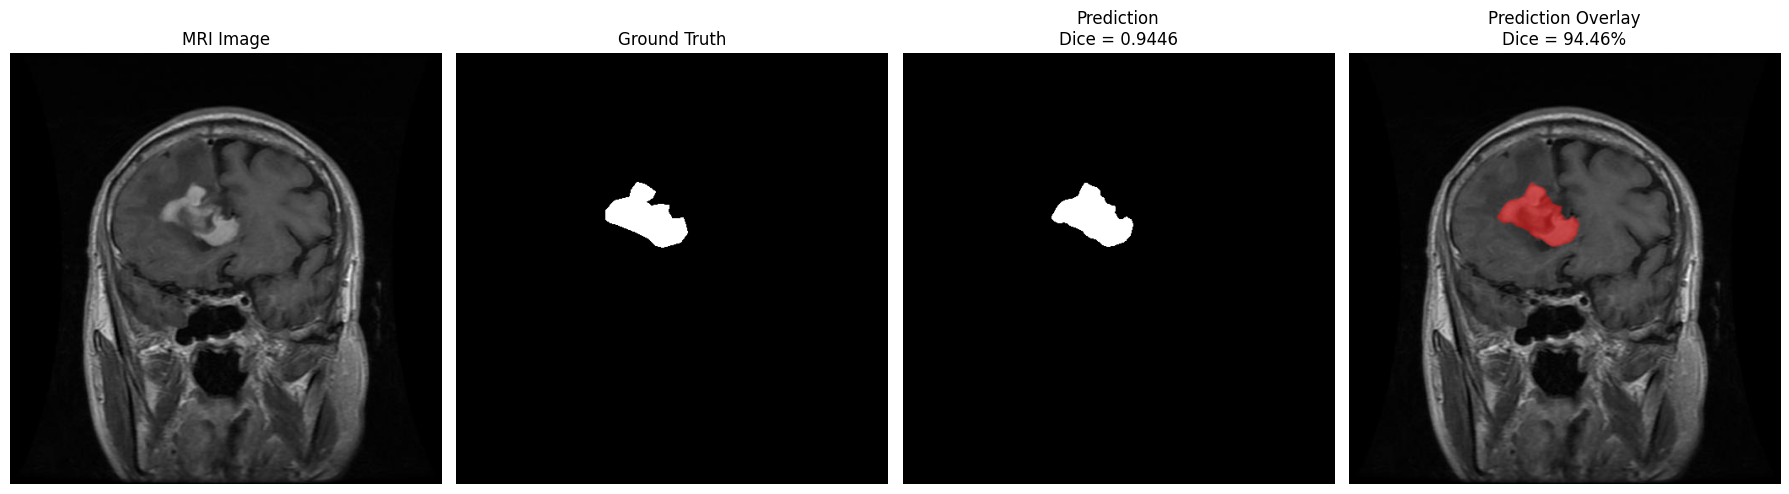

Dice Score for this image: 0.9446 (94.46%)


np.float32(0.9446279)

In [67]:
visualize_prediction(
    model=model,
    image_path=image_path,
    mask_path=mask_path,
    device=device,
    img_size=512,
    threshold=0.5
)

Test sample:
brisc2025_train_00426_gl_co_t1

Loading unetplusplus...

Loading efficientnet_b1_unet...

Loading attention_unet...

Loading resunet...

Loading unetplusplus_efficientnet_b1...


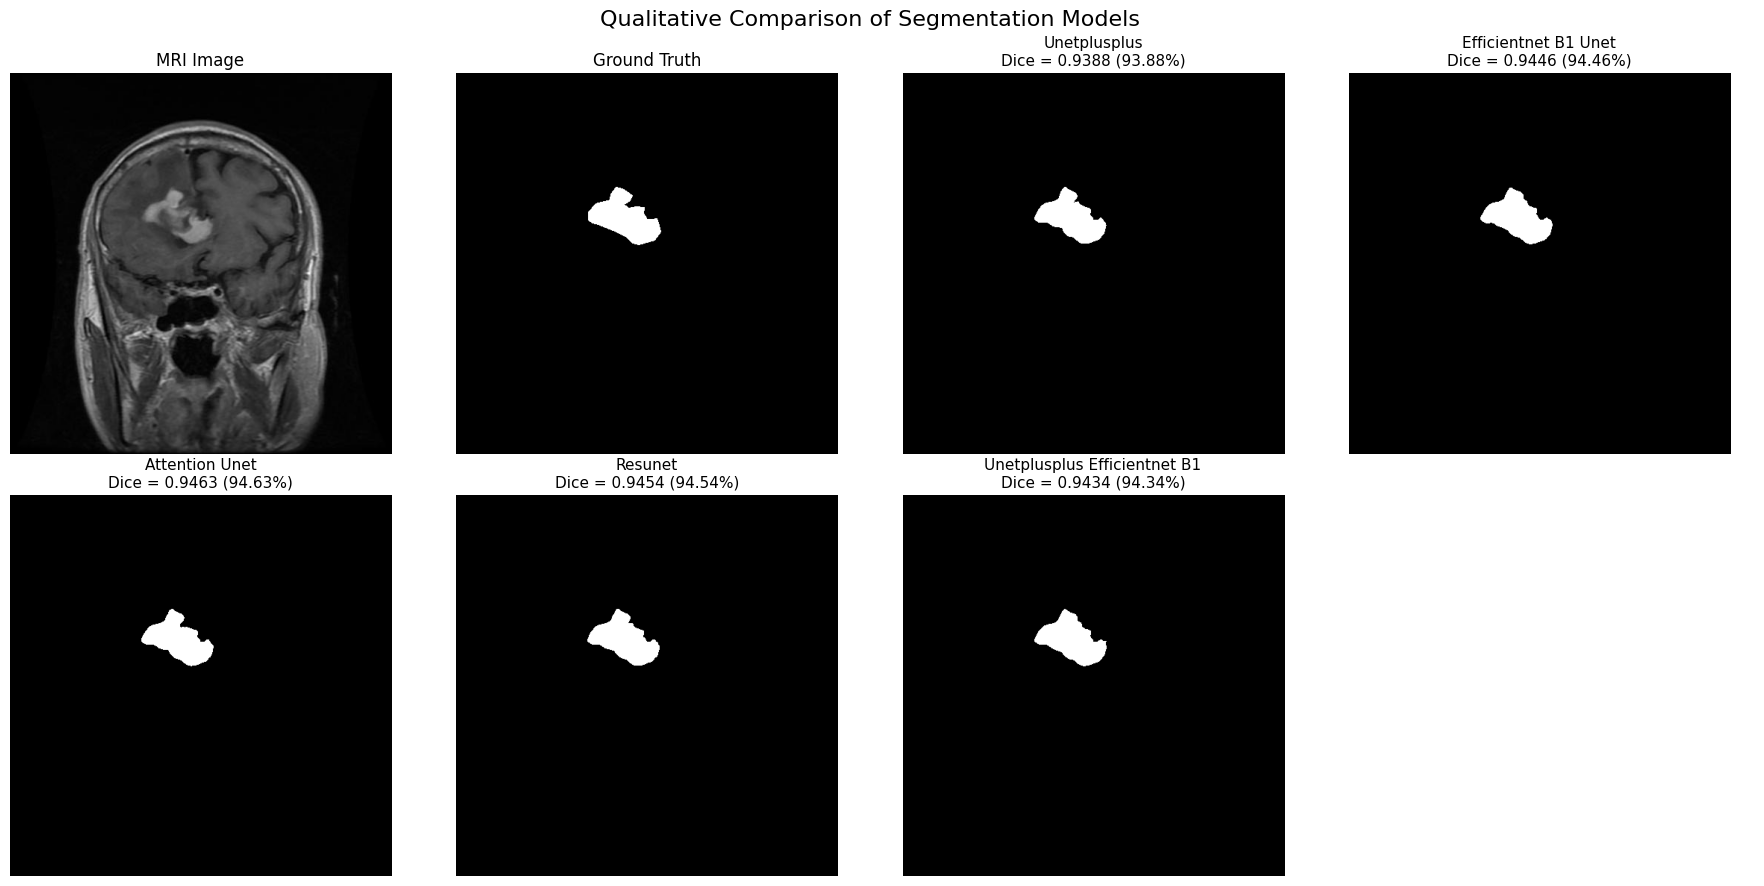


DICE SCORES FOR THIS TEST IMAGE
unetplusplus                             0.9388 (93.88%)
efficientnet_b1_unet                     0.9446 (94.46%)
attention_unet                           0.9463 (94.63%)
resunet                                  0.9454 (94.54%)
unetplusplus_efficientnet_b1             0.9434 (94.34%)


In [62]:
# Compare all trained models on the same test image

import os
import numpy as np
import torch
import matplotlib.pyplot as plt
from PIL import Image


# ---------------------------------------------------------------
# Models
# ---------------------------------------------------------------

model_names = [
    'unetplusplus',
    'efficientnet_b1_unet',
    'attention_unet',
    'resunet',
    'unetplusplus_efficientnet_b1'
]


device = (
    'cuda'
    if torch.cuda.is_available()
    else 'cpu'
)


# ---------------------------------------------------------------
# Select the same test image
# ---------------------------------------------------------------

sample_name = seg_split['test_internal'][8]

image_path = os.path.join(
    images_dir,
    sample_name + '.jpg'
)

mask_path = os.path.join(
    masks_dir,
    sample_name + '.png'
)

print("Test sample:")
print(sample_name)


# ---------------------------------------------------------------
# Load image and ground truth
# ---------------------------------------------------------------

image = np.array(
    Image.open(image_path).convert('RGB')
)

ground_truth = np.array(
    Image.open(mask_path).convert('L')
)

ground_truth = (
    ground_truth > 127
).astype(np.float32)


# ---------------------------------------------------------------
# Apply evaluation preprocessing
# ---------------------------------------------------------------

transform = get_segmentation_eval_transforms(
    img_size=512
)

transformed = transform(
    image=image,
    mask=ground_truth
)

input_tensor = (
    transformed['image']
    .unsqueeze(0)
    .to(device)
)


# ---------------------------------------------------------------
# Prepare images for display
# ---------------------------------------------------------------

display_image = np.array(
    Image.fromarray(image).resize(
        (512, 512)
    )
)

ground_truth_display = (
    transformed['mask']
    .cpu()
    .numpy()
)

if ground_truth_display.ndim == 3:
    ground_truth_display = ground_truth_display[0]

ground_truth_display = (
    ground_truth_display > 0.5
).astype(np.float32)


# ---------------------------------------------------------------
# Create figure
# 2 rows × 4 columns = 8 slots
# ---------------------------------------------------------------

fig, axes = plt.subplots(
    2,
    4,
    figsize=(18, 9)
)

axes = axes.flatten()


# ---------------------------------------------------------------
# Original MRI
# ---------------------------------------------------------------

axes[0].imshow(display_image)

axes[0].set_title(
    "MRI Image",
    fontsize=12
)

axes[0].axis("off")


# ---------------------------------------------------------------
# Ground Truth
# ---------------------------------------------------------------

axes[1].imshow(
    ground_truth_display,
    cmap="gray"
)

axes[1].set_title(
    "Ground Truth",
    fontsize=12
)

axes[1].axis("off")


# ---------------------------------------------------------------
# Generate predictions for all models
# ---------------------------------------------------------------

dice_scores = {}


for idx, model_name in enumerate(model_names):

    print(
        f"\nLoading {model_name}..."
    )

    # -----------------------------------------------------------
    # Checkpoint path
    # -----------------------------------------------------------

    checkpoint_path = os.path.join(
        PROJECT_ROOT,
        'BrainTumor-Segmentation-Results',
        model_name,
        'seed_42',
        'best_model.pt'
    )

    # -----------------------------------------------------------
    # Check checkpoint
    # -----------------------------------------------------------

    if not os.path.exists(checkpoint_path):

        print(
            f"WARNING: checkpoint not found:\n"
            f"{checkpoint_path}"
        )

        axes[idx + 2].axis("off")

        continue


    # -----------------------------------------------------------
    # Create model
    # -----------------------------------------------------------

    model = get_segmentation_model(
        model_name
    ).to(device)


    # -----------------------------------------------------------
    # Load checkpoint
    # -----------------------------------------------------------

    model.load_state_dict(
        torch.load(
            checkpoint_path,
            map_location=device
        )
    )

    model.eval()


    # -----------------------------------------------------------
    # Prediction
    # -----------------------------------------------------------

    with torch.no_grad():

        logits = model(
            input_tensor
        )

        probabilities = torch.sigmoid(
            logits
        )

        prediction = (
            probabilities > 0.5
        ).float()


    prediction = (
        prediction[0, 0]
        .cpu()
        .numpy()
    )

    prediction = (
        prediction > 0.5
    ).astype(np.float32)


    # -----------------------------------------------------------
    # Calculate Dice score
    # -----------------------------------------------------------

    intersection = np.sum(
        prediction * ground_truth_display
    )

    prediction_area = np.sum(
        prediction
    )

    ground_truth_area = np.sum(
        ground_truth_display
    )

    dice_score = (
        (2.0 * intersection + 1e-7)
        /
        (
            prediction_area
            + ground_truth_area
            + 1e-7
        )
    )

    dice_scores[model_name] = dice_score


    # -----------------------------------------------------------
    # Display prediction
    # -----------------------------------------------------------

    axes[idx + 2].imshow(
        prediction,
        cmap="gray"
    )

    axes[idx + 2].set_title(
        f"{model_name.replace('_', ' ').title()}\n"
        f"Dice = {dice_score:.4f} "
        f"({dice_score * 100:.2f}%)",
        fontsize=11
    )

    axes[idx + 2].axis("off")


    # -----------------------------------------------------------
    # Clean memory
    # -----------------------------------------------------------

    del model

    if torch.cuda.is_available():
        torch.cuda.empty_cache()


# ---------------------------------------------------------------
# Hide unused 8th subplot
# ---------------------------------------------------------------

axes[7].axis("off")


# ---------------------------------------------------------------
# Overall title
# ---------------------------------------------------------------

plt.suptitle(
    "Qualitative Comparison of Segmentation Models",
    fontsize=16
)

plt.tight_layout()

plt.show()


# ---------------------------------------------------------------
# Print Dice scores
# ---------------------------------------------------------------

print("\n" + "=" * 60)
print("DICE SCORES FOR THIS TEST IMAGE")
print("=" * 60)

for model_name, dice_score in dice_scores.items():

    print(
        f"{model_name:<40} "
        f"{dice_score:.4f} "
        f"({dice_score * 100:.2f}%)"
    )